In [1]:
# SEKCJA 1: SETUP I TRENING MODELU WALIDACYJNEGO

import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.signal import resample_poly

os.environ["LOKY_MAX_CPU_COUNT"] = "1"
plt.rcParams['text.usetex'] = False  
sns.set_theme(style="whitegrid")
RANDOM_SEED = 42

def map_name(name):
    # Normalizacja nazw klas
    name = str(name).strip().lower()
    if 'healthy' in name: return 'Healthy State'
    elif 'elec' in name and 'mech' in name: return 'Mixed Fault Condition'
    elif 'elec' in name: return 'Electrical Fault'
    elif 'mech' in name: return 'Mechanical Fault'
    return None

def train_verification_model():
    # Wczytanie i czyszczenie danych
    df = pd.read_csv("motors.csv", sep=None, engine='python')
    df = df.drop(columns=[c for c in df.columns if c.startswith("is_") or "Unnamed" in c], errors="ignore")
    
    df['Class'] = df['Class'].apply(map_name)
    df = df.dropna(subset=['Class'])
    
    # Wybór cech
    feature_names = [c for c in df.columns if "CURRENT" in c.upper() or "ROTO" in c.upper()]
    if not feature_names:
        raise ValueError("No diagnostic features matching CURRENT/ROTO pattern were found.")
    
    X = df[feature_names].replace([np.inf, -np.inf], np.nan).dropna()
    y = df.loc[X.index, "Class"]

    print(f"Training samples: {len(X)}")
    print(f"Features count: {len(feature_names)}")

    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    # Definicja estymatorów
    estimators = [
        ('rf_std', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=1)),
        ('rf_shallow', RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=1)),
        ('rf_dense', RandomForestClassifier(n_estimators=500, min_samples_split=2, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=1))
    ]
    
    stacking_model = StackingClassifier(
        estimators=estimators, 
        final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'), 
        stack_method='predict_proba', cv=cv_strategy, n_jobs=1
    )
    
    # Budowa pipeline z automatycznym skalowaniem
    full_verification_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', stacking_model)
    ])
    
    full_verification_pipeline.fit(X, y)
    return full_verification_pipeline, feature_names, stacking_model.classes_

# Inicjalizacja modelu
model, feature_names, _ = train_verification_model()
class_names = model.named_steps['clf'].classes_
pretty_class_names = [str(c) for c in class_names]

new_files = sorted(glob.glob('Faulty-*.csv') + glob.glob('Healthy-*.csv'))

Training samples: 184
Features count: 26



External Motor Validation Results:
                 Unit            Condition       Prediction                    Interpretation  Confidence
 Faulty-1-zipcord.csv PM Fault + Imbalance Mechanical Fault              Mechanical dominance    0.728316
         Faulty-1.csv             PM Fault Mechanical Fault Cross-domain mechanical signature    0.752399
 Faulty-2-zipcord.csv PM Fault + Imbalance    Healthy State                        Unexpected    0.529068
         Faulty-2.csv             PM Fault    Healthy State                        Unexpected    0.493473
 Faulty-3-zipcord.csv PM Fault + Imbalance Electrical Fault              Electrical dominance    0.855049
         Faulty-3.csv             PM Fault Electrical Fault                          Expected    0.838579
Healthy-1-zipcord.csv  Healthy + Imbalance Mechanical Fault                          Expected    0.732431
        Healthy-1.csv        Healthy Motor    Healthy State                          Expected    0.616420
Healthy-2-

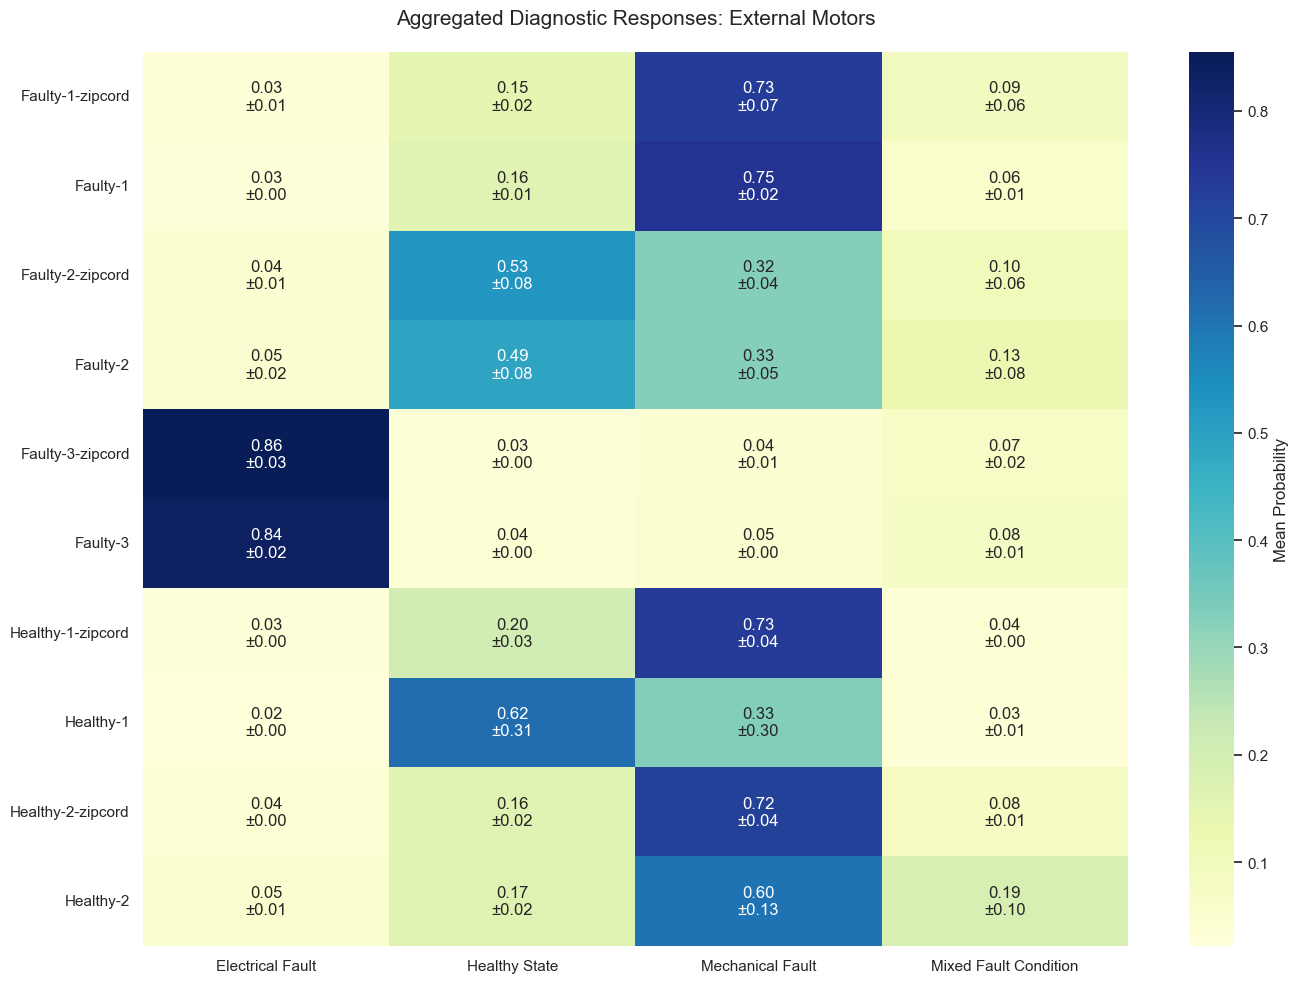

In [2]:
# SEKCJA 2: ANALIZA WALIDACJI ZEWNĘTRZNEJ

def infer_physical_condition(filename):
    f = filename.lower()
    if 'healthy' in f and 'zipcord' not in f: return 'Healthy Motor'
    if 'healthy' in f and 'zipcord' in f: return 'Healthy + Imbalance'
    if 'faulty' in f and 'zipcord' not in f: return 'PM Fault'
    if 'faulty' in f and 'zipcord' in f: return 'PM Fault + Imbalance'
    return 'Unknown'

def get_diagnostic_interpretation(condition, predicted):
    if condition == 'Healthy Motor' and predicted == 'Healthy State': return 'Expected'
    if condition == 'Healthy + Imbalance' and predicted == 'Mechanical Fault': return 'Expected'
    if condition == 'PM Fault':
        if predicted == 'Electrical Fault': return 'Expected'
        if predicted == 'Mechanical Fault': return 'Cross-domain mechanical signature'
    if condition == 'PM Fault + Imbalance':
        if predicted == 'Mechanical Fault': return 'Mechanical dominance'
        if predicted == 'Electrical Fault': return 'Electrical dominance'
        if predicted == 'Mixed Fault Condition': return 'Mixed signature detected'
    return 'Unexpected'

# Inicjalizacja list wynikowych
unit_results, means, stds, file_labels = [], [], [], []
original_test_files = [f for f in new_files if "-10khz" not in f]

# Pętla walidacyjna po plikach zewnętrznych
for file in original_test_files:
    df_new = pd.read_csv(file, sep=None, engine='python')
    if 'Experiment ID' in df_new.columns:
        df_new = df_new[df_new['Experiment ID'] != 0]
    
    if not df_new.empty:
        probs = model.predict_proba(df_new[feature_names])
        m_probs = np.mean(probs, axis=0)
        
        final_idx = np.argmax(m_probs)
        physical_cond = infer_physical_condition(file)
        
        res_entry = {
            'Unit': file,
            'Condition': physical_cond,
            'Prediction': class_names[final_idx],
            'Interpretation': get_diagnostic_interpretation(physical_cond, class_names[final_idx]),
            'Confidence': m_probs[final_idx]
        }
        unit_results.append(res_entry)
        means.append(m_probs)
        stds.append(np.std(probs, axis=0))
        file_labels.append(file.replace(".csv", "").replace("_", " "))

# Zapis wyników do pliku i wyświetlenie w konsoli
df_unit = pd.DataFrame(unit_results)
df_unit.to_csv("unit_level_results.csv", index=False)
print("\nExternal Motor Validation Results:")
print(df_unit[['Unit', 'Condition', 'Prediction', 'Interpretation', 'Confidence']].to_string(index=False))

# Wizualizacja zagregowanych wyników
plt.figure(figsize=(14, 10))
df_means = pd.DataFrame(means, index=file_labels, columns=pretty_class_names)
annot = [[f"{m:.2f}\n±{s:.2f}" for m, s in zip(m_r, s_r)] for m_r, s_r in zip(df_means.values, stds)]

sns.heatmap(df_means, annot=annot, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Mean Probability'})
plt.title("Aggregated Diagnostic Responses: External Motors", fontsize=15, pad=20)
plt.tight_layout()
plt.savefig("external_validation_heatmap.png", dpi=200)
plt.show()

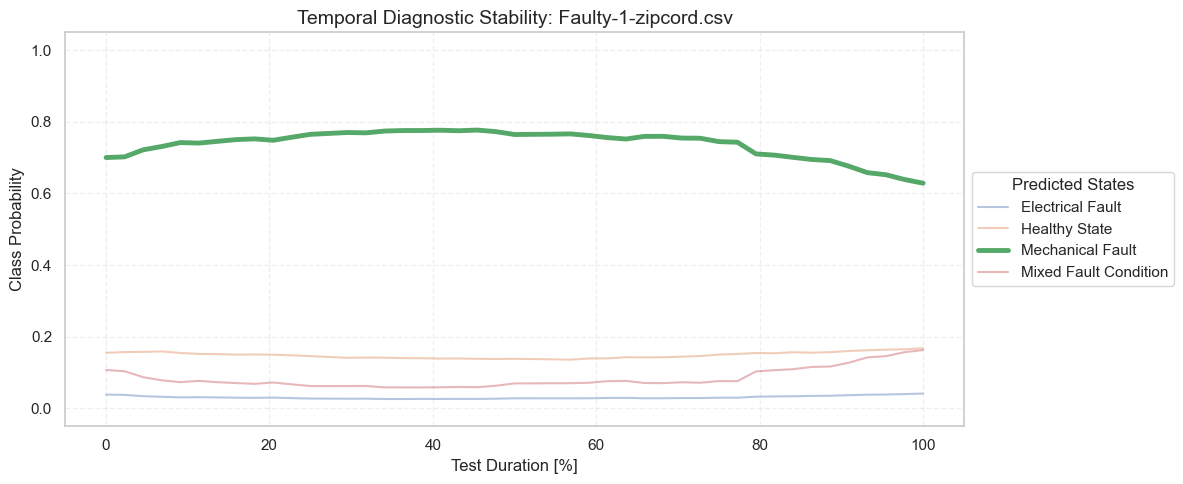

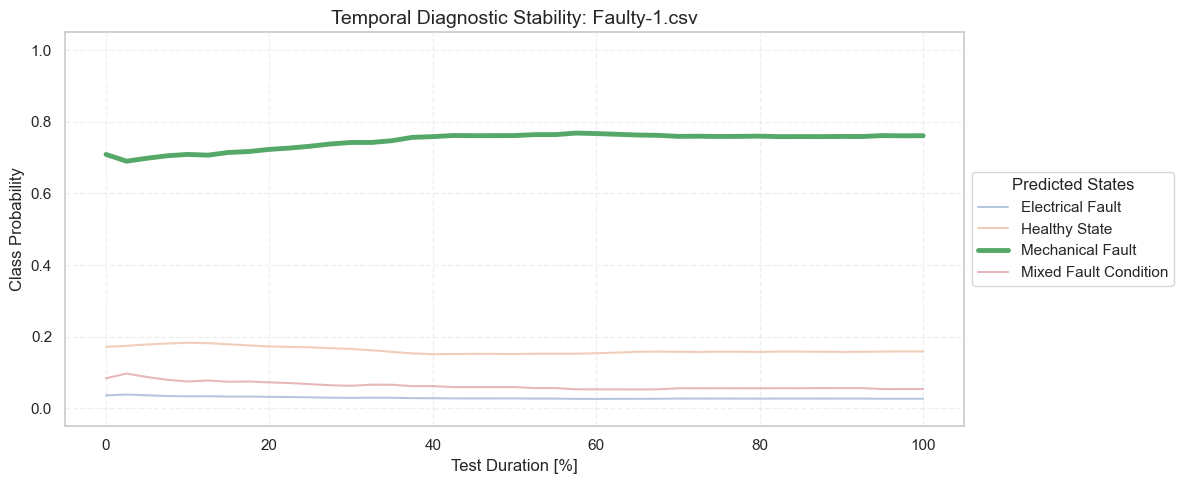

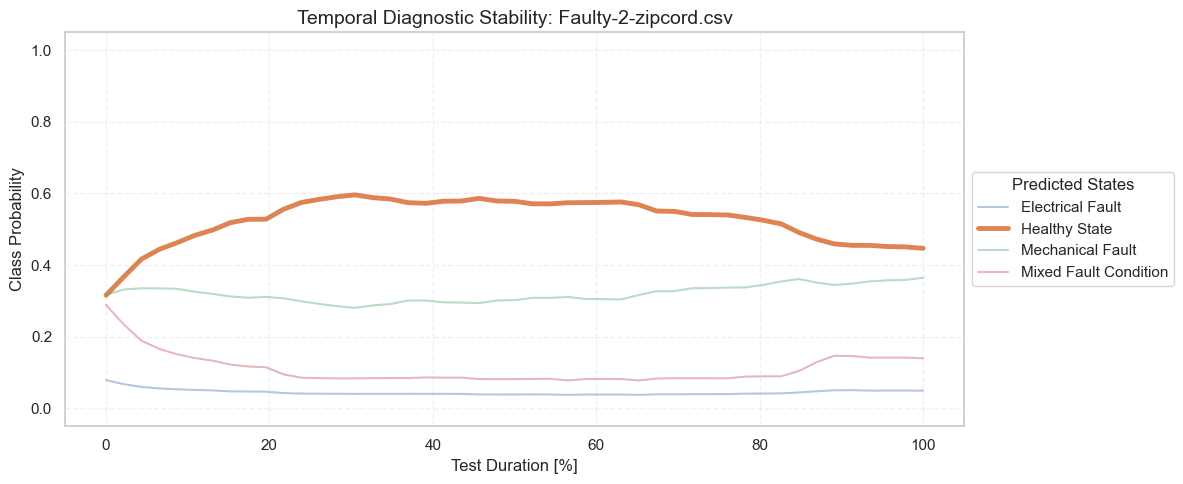

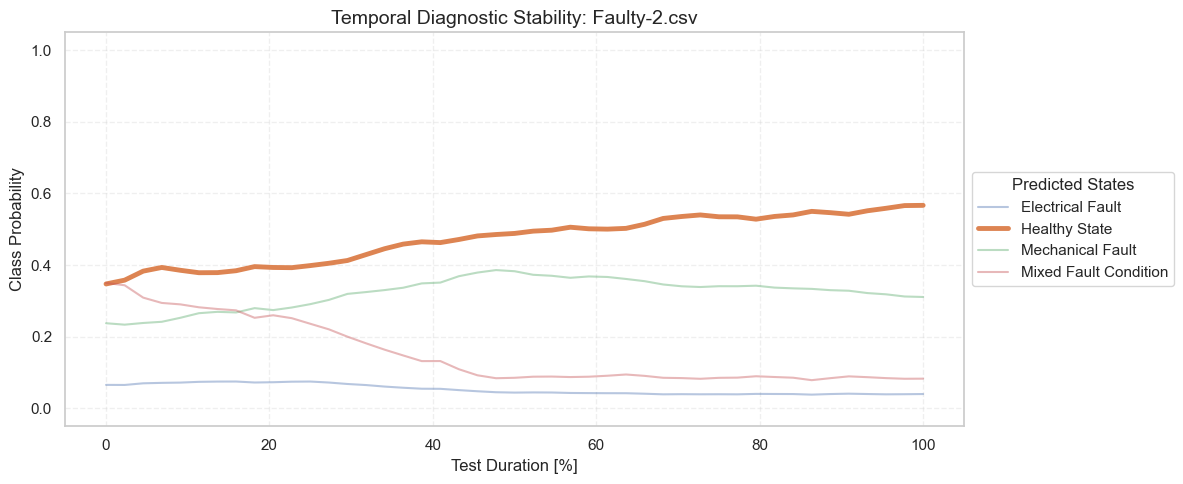

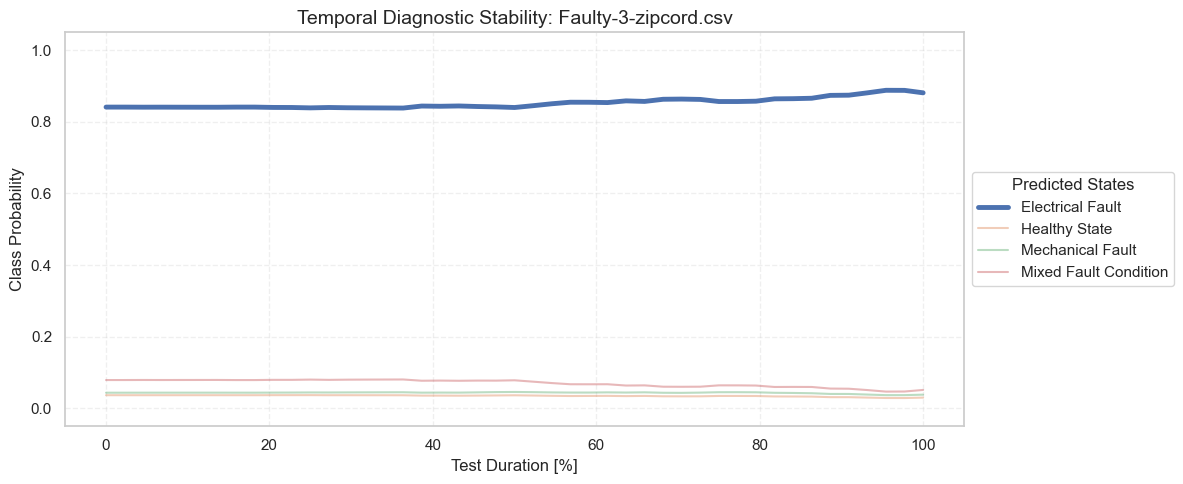

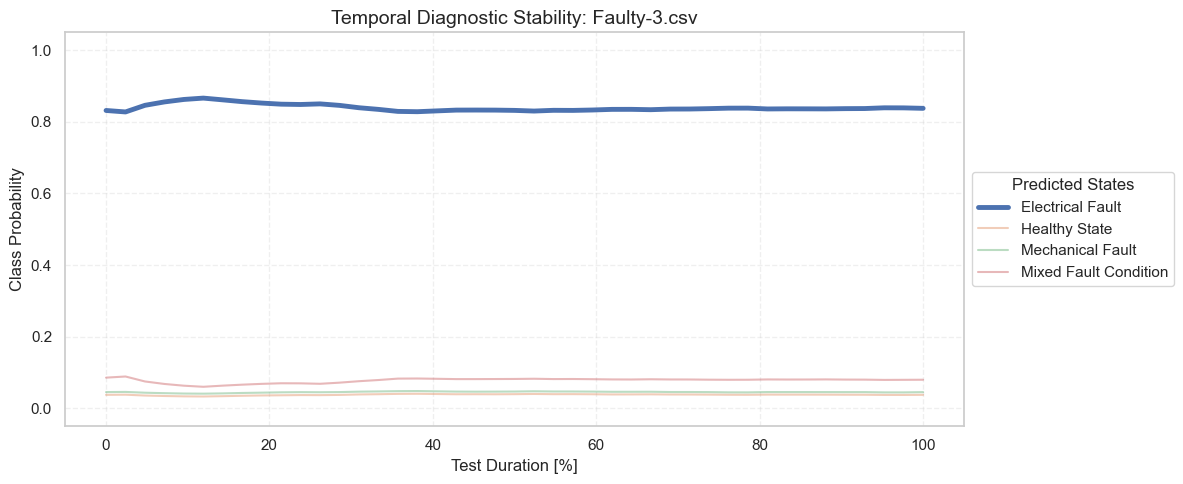

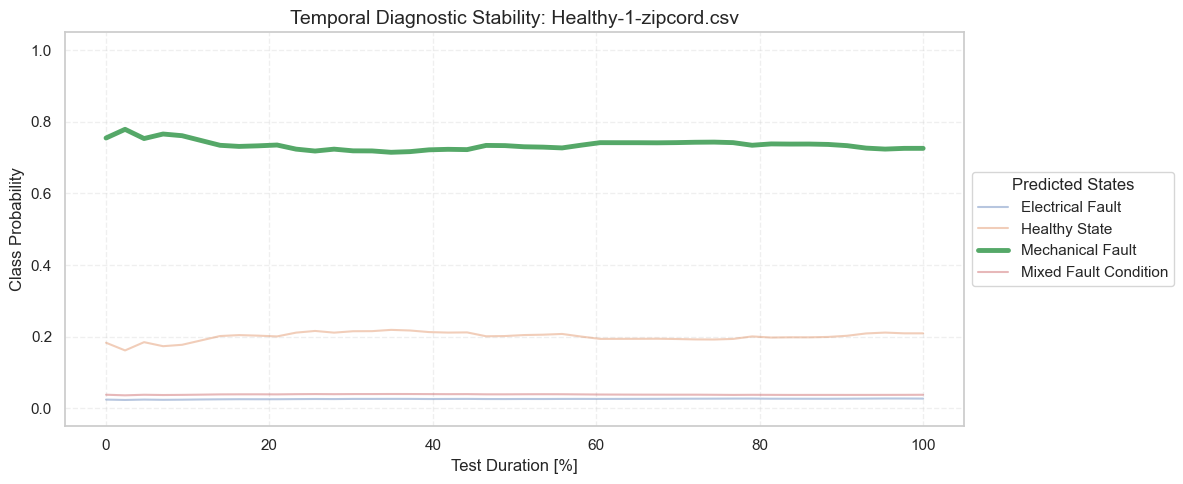

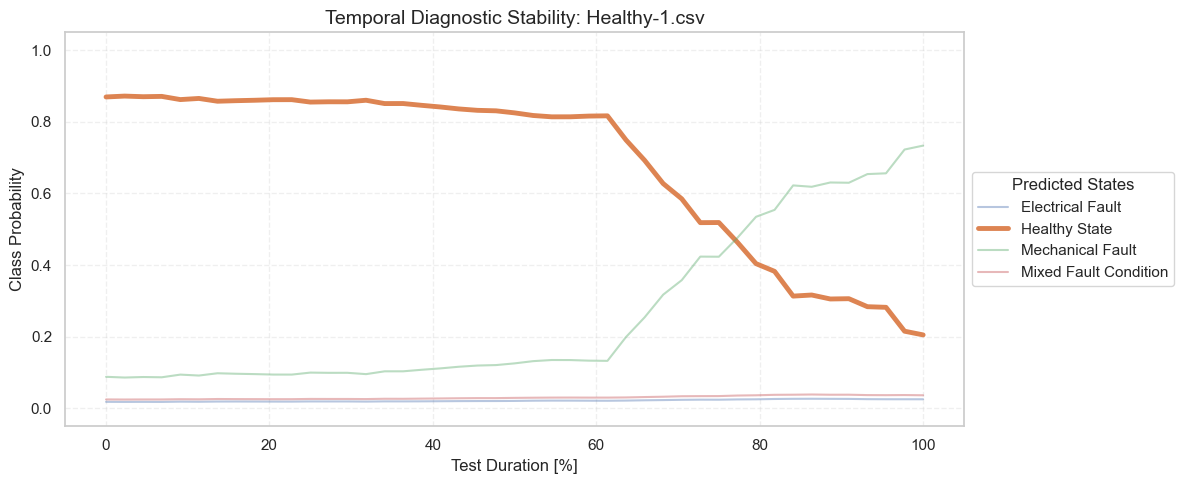

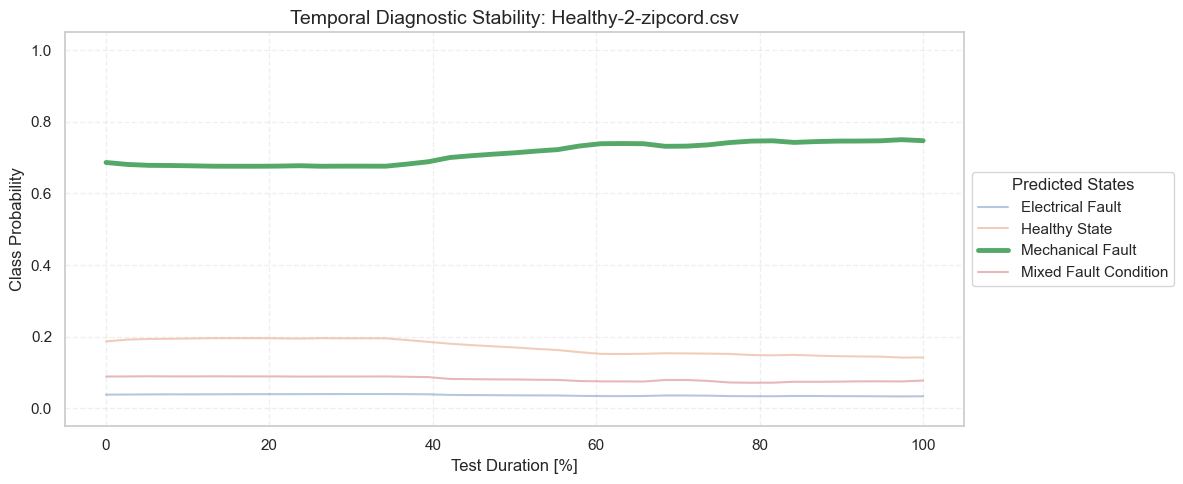

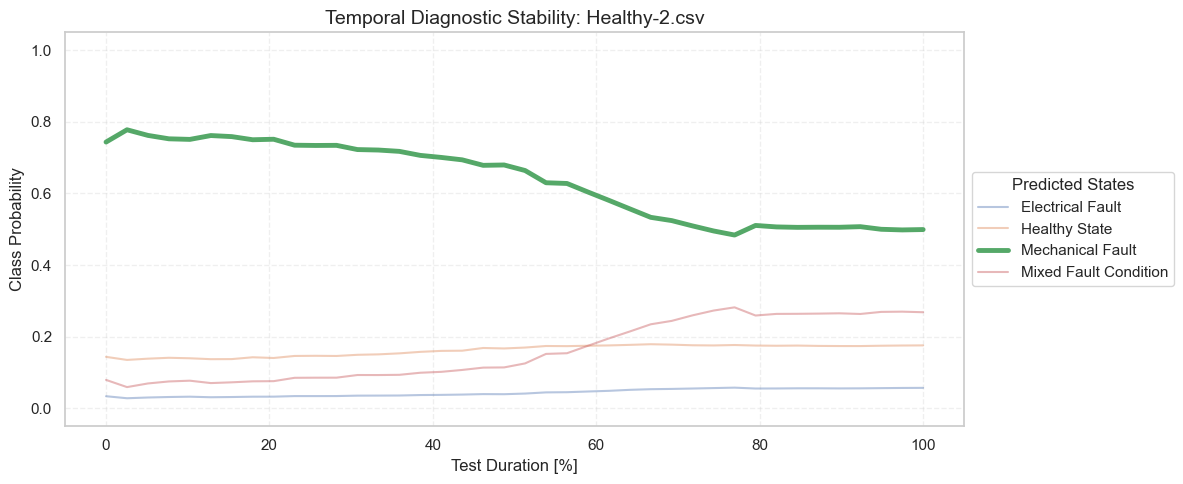


Global Stability Metrics:
Mean Window Agreement: 96.23%
Mean Diagnostic Margin: 0.4875
Mean Volatility: 0.0802


In [3]:
# SEKCJA 3: ANALIZA STABILNOŚCI CZASOWEJ

temporal_results = []
original_test_files = [f for f in new_files if "-10khz" not in f]

for file in original_test_files:
    df_step = pd.read_csv(file, sep=None, engine='python')
    if 'Experiment ID' in df_step.columns:
        df_step = df_step[df_step['Experiment ID'] != 0]
    
    if not df_step.empty:
        probs = model.predict_proba(df_step[feature_names])
        window_preds = np.argmax(probs, axis=1)

        m_probs = np.mean(probs, axis=0)
        dominant_idx = np.argmax(m_probs)
        
        sorted_m_probs = np.sort(m_probs)
        diag_margin = sorted_m_probs[-1] - sorted_m_probs[-2]
        
        # Obliczenia metryk stabilności czasowej
        temporal_results.append({
            'File': file,
            'Dominant State': class_names[dominant_idx],
            'Agreement': np.mean(window_preds == dominant_idx),
            'Switch Rate': np.sum(window_preds[:-1] != window_preds[1:]) / max(len(window_preds) - 1, 1),
            'Mean Prob': m_probs[dominant_idx],
            'Margin': diag_margin,
            'Volatility': np.std(probs[:, dominant_idx])
        })

        # Wizualizacja trajektorii prawdopodobieństw w czasie
        plt.figure(figsize=(12, 5))
        x_axis = np.linspace(0, 100, len(probs))
        
        for i, label in enumerate(pretty_class_names):
            smooth_probs = pd.Series(probs[:, i]).rolling(window=10, min_periods=1).mean()
            is_dominant = (i == dominant_idx)
            plt.plot(x_axis, smooth_probs, label=label, linewidth=3.5 if is_dominant else 1.5, alpha=1.0 if is_dominant else 0.4)
            
        plt.title(f"Temporal Diagnostic Stability: {file}", fontsize=14)
        plt.xlabel("Test Duration [%]")
        plt.ylabel("Class Probability") 
        plt.ylim(-0.05, 1.05)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Predicted States")
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig(f"stability_{os.path.basename(file).split('.')[0]}.png", dpi=200)
        plt.show()

# Globalne podsumowanie stabilności
if temporal_results:
    df_temp = pd.DataFrame(temporal_results)
    df_temp.to_csv("temporal_stability_results.csv", index=False)
    
    print("\nGlobal Stability Metrics:")
    print(f"Mean Window Agreement: {df_temp['Agreement'].mean():.2%}")
    print(f"Mean Diagnostic Margin: {df_temp['Margin'].mean():.4f}")
    print(f"Mean Volatility: {df_temp['Volatility'].mean():.4f}")

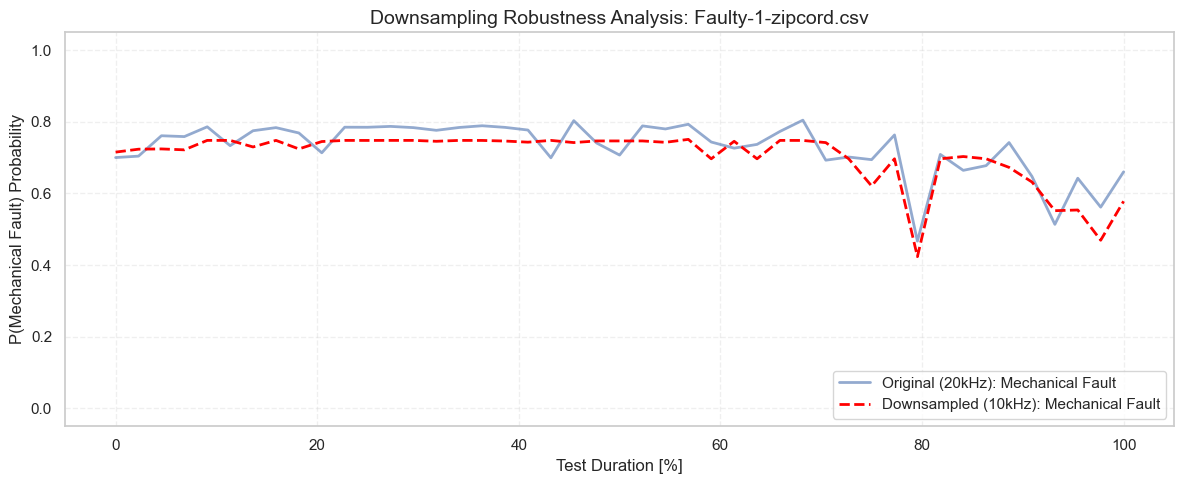

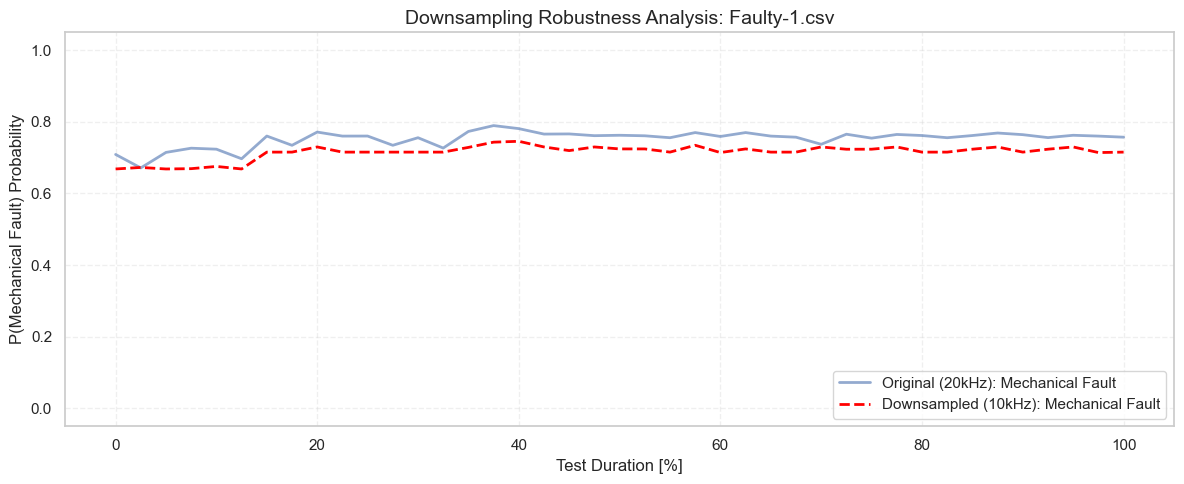

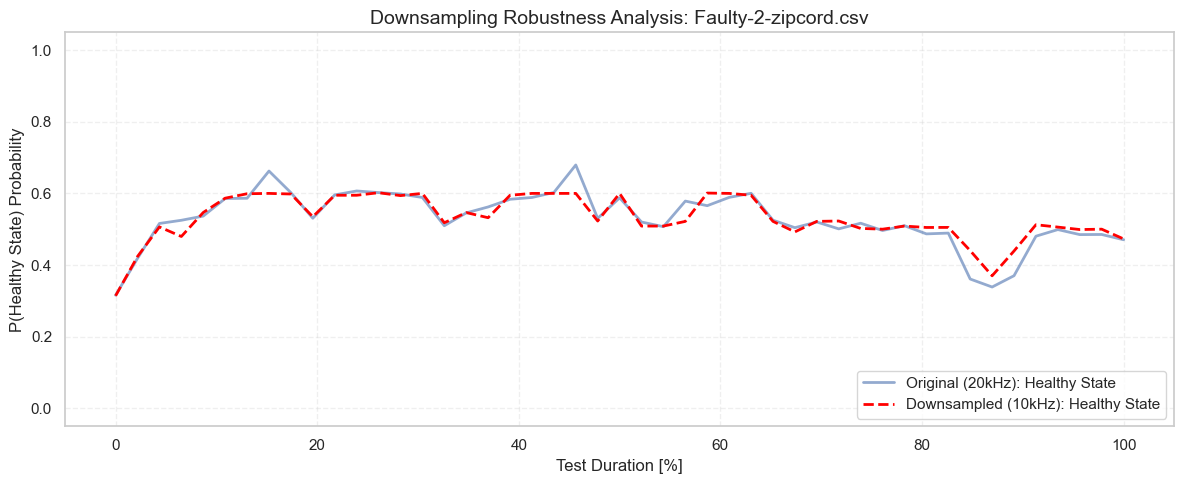

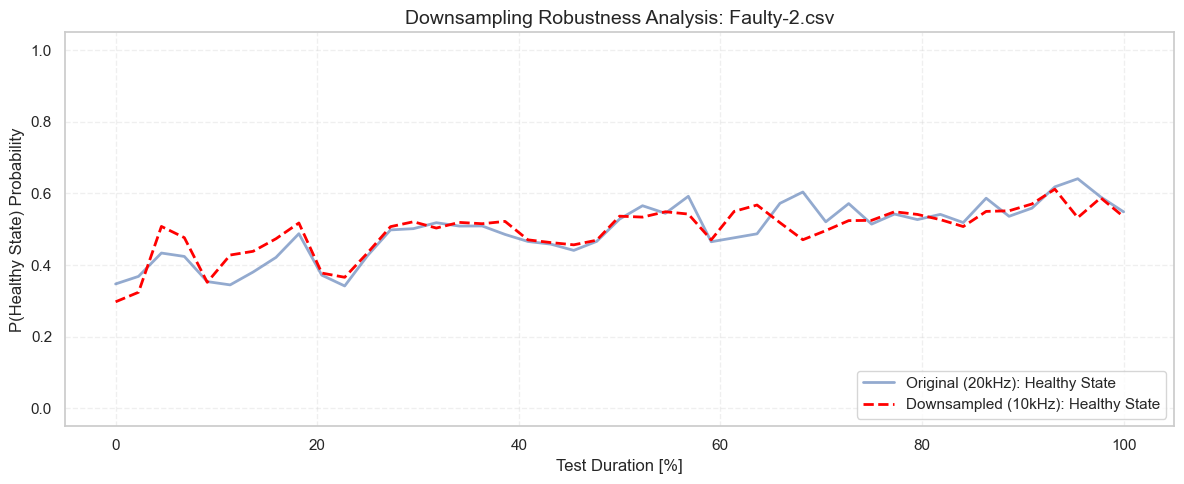

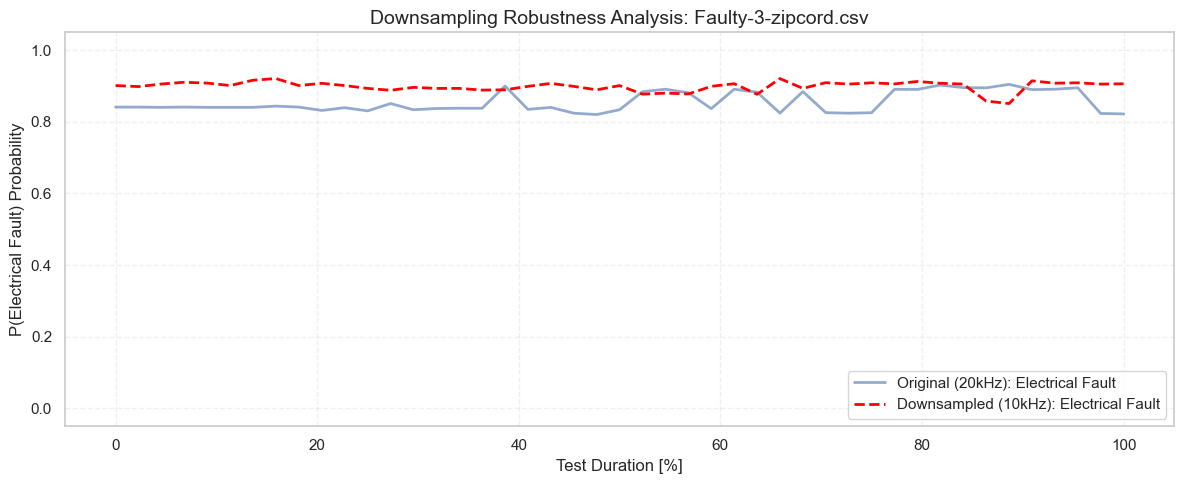

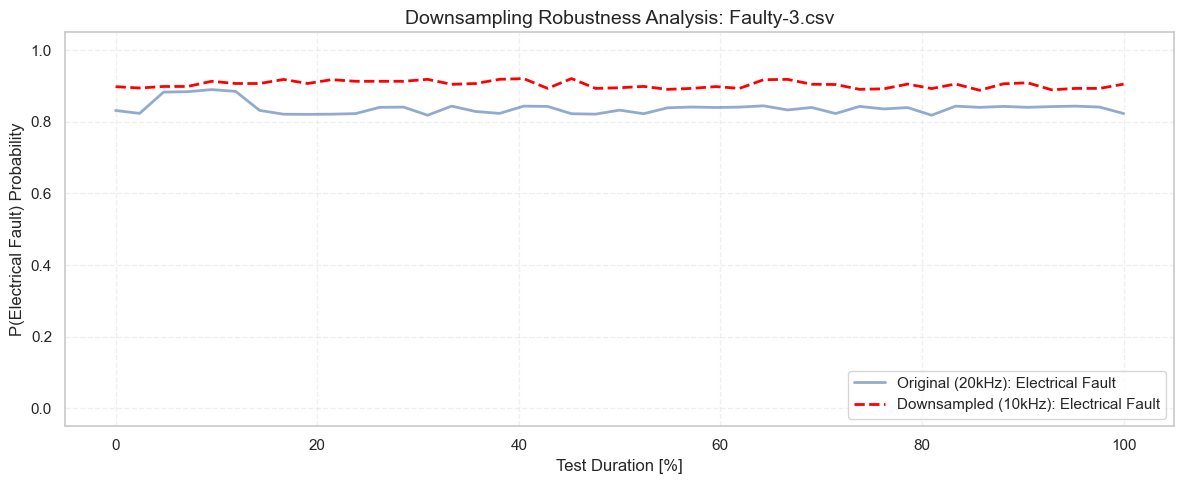

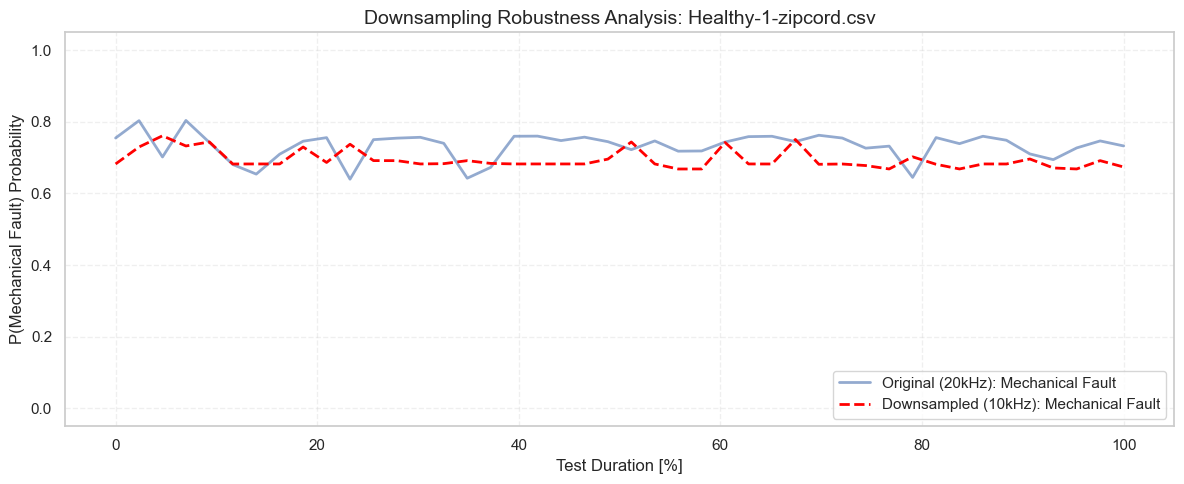

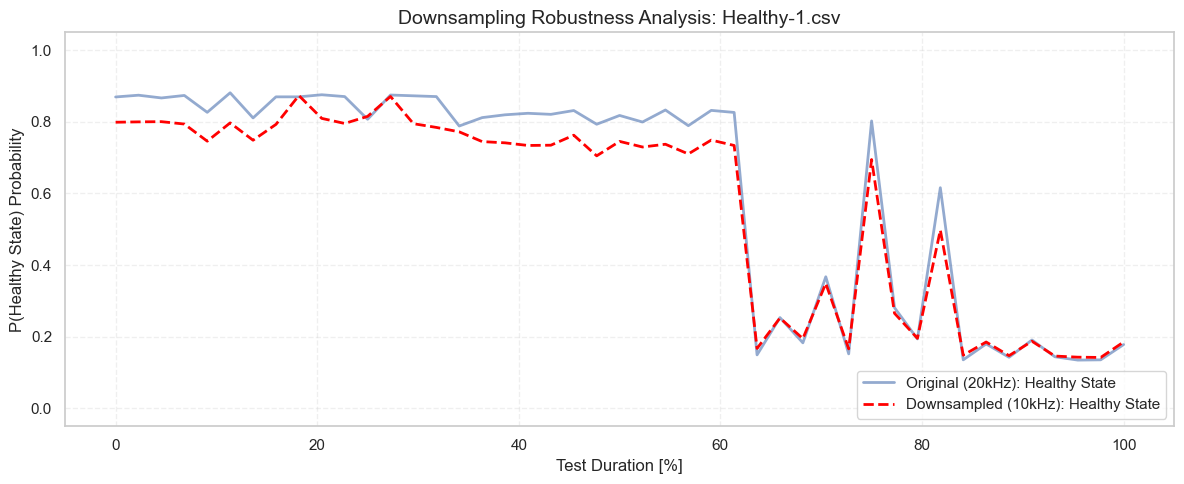

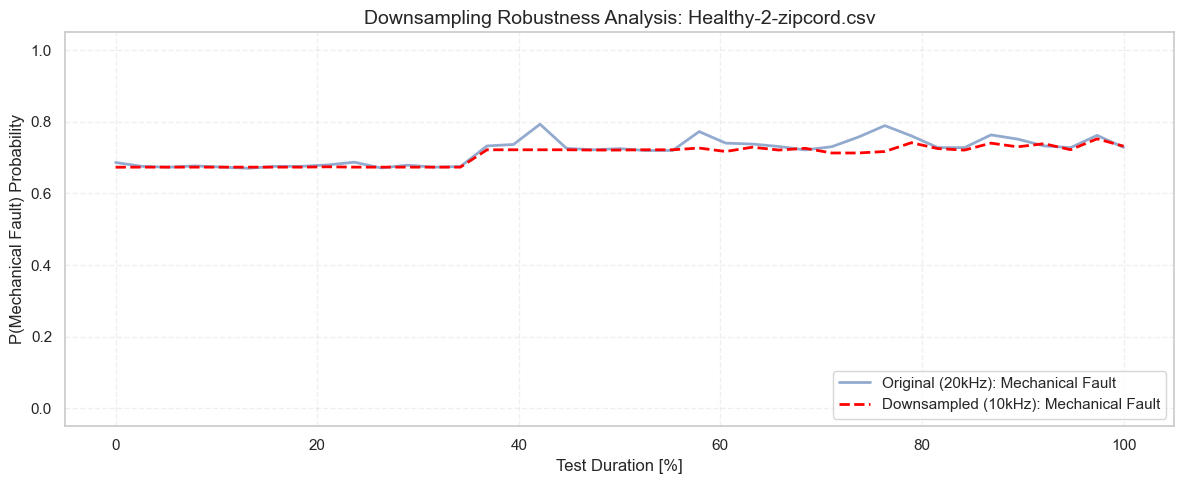

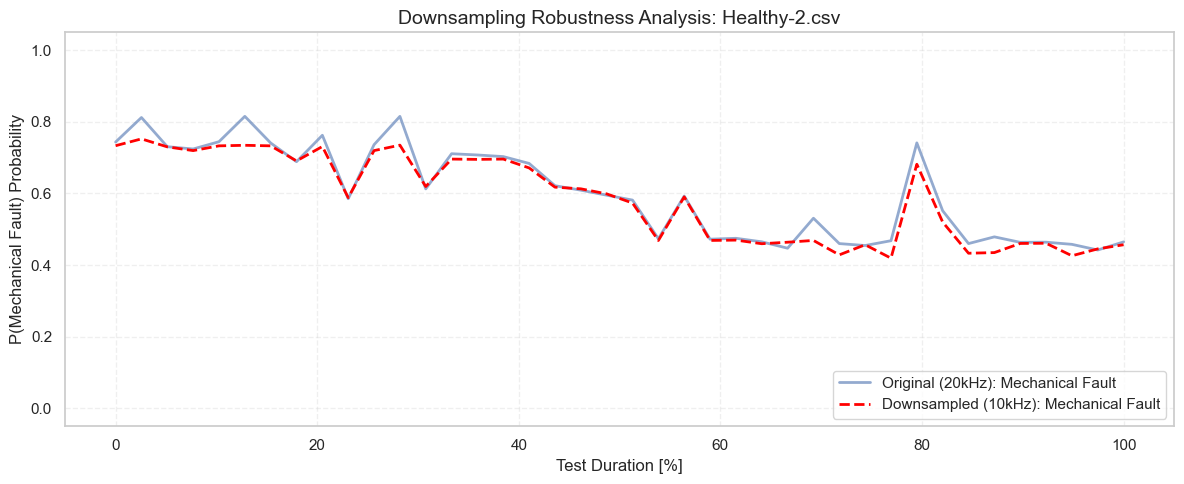

UNIT-LEVEL RESULTS
--------------------------------------------------------------------------------------------------------------
      File Identifier Original FS Resampled FS   Original State  Resampled State  Prediction Stable Original Conf. Resampled Conf. Delta Conf.  Mean Abs Prob Shift
 Faulty-1-zipcord.csv      20 kHz       10 kHz Mechanical Fault Mechanical Fault               True         72.83%          70.33%      -2.50%               0.0129
         Faulty-1.csv      20 kHz       10 kHz Mechanical Fault Mechanical Fault               True         75.24%          71.50%      -3.74%               0.0187
 Faulty-2-zipcord.csv      20 kHz       10 kHz    Healthy State    Healthy State               True         52.91%          53.08%      +0.18%               0.0041
         Faulty-2.csv      20 kHz       10 kHz    Healthy State    Healthy State               True         49.35%          49.53%      +0.18%               0.0056
 Faulty-3-zipcord.csv      20 kHz       10 kHz Ele

In [11]:
# SEKCJA 4: DOWNSAMPLING SYGNAŁÓW (20 kHz → 10 kHz)

resampling_results = []
original_files = [f for f in new_files if "-10khz" not in f]

for file in original_files:
    resampled_file = file.replace('.csv', '-10khz.csv')
    
    if not os.path.exists(resampled_file):
        continue

    # Wczytanie i czyszczenie danych
    df_orig = pd.read_csv(file, sep=None, engine='python')
    if 'Experiment ID' in df_orig.columns:
        df_orig = df_orig[df_orig['Experiment ID'] != 0]
    
    df_res = pd.read_csv(resampled_file, sep=None, engine='python')
    if 'Experiment ID' in df_res.columns:
        df_res = df_res[df_res['Experiment ID'] != 0]

    # Porównanie predykcji
    if not df_orig.empty and not df_res.empty:
        probs_orig = model.predict_proba(df_orig[feature_names])
        m_probs_orig = np.mean(probs_orig, axis=0)
        idx_orig = np.argmax(m_probs_orig) 
        
        probs_res = model.predict_proba(df_res[feature_names])
        m_probs_res = np.mean(probs_res, axis=0)
        idx_res = np.argmax(m_probs_res) 
        
        # Analiza stabilności wyniku
        prediction_stable = class_names[idx_orig] == class_names[idx_res]
        prob_shift = np.mean(np.abs(m_probs_orig - m_probs_res))
        
        resampling_results.append({
            'File Identifier': file,
            'Original FS': '20 kHz',
            'Resampled FS': '10 kHz',
            'Original State': class_names[idx_orig],
            'Resampled State': class_names[idx_res],
            'Prediction Stable': prediction_stable,
            'Original Conf.': m_probs_orig[idx_orig],
            'Resampled Conf.': m_probs_res[idx_res],
            'Delta Conf.': m_probs_res[idx_res] - m_probs_orig[idx_orig],
            'Mean Abs Prob Shift': round(prob_shift, 4)
        })

        # Wizualizacja trajektorii prawdopodobieństw
        plt.figure(figsize=(12, 5))
        x_orig = np.linspace(0, 100, len(probs_orig))
        x_res = np.linspace(0, 100, len(probs_res))
        
        plt.plot(x_orig, probs_orig[:, idx_orig], 
                 label=f'Original (20kHz): {pretty_class_names[idx_orig]}', 
                 alpha=0.6, linewidth=2)
        
        plt.plot(x_res, probs_res[:, idx_orig], 
                 label=f'Downsampled (10kHz): {pretty_class_names[idx_orig]}', 
                 linestyle='--', color='red', linewidth=2)

        plt.title(f"Downsampling Robustness Analysis: {file}", fontsize=14)
        plt.ylabel(f"P({pretty_class_names[idx_orig]}) Probability")
        plt.xlabel("Test Duration [%]")
        plt.ylim(-0.05, 1.05)
        plt.legend(loc='lower right', frameon=True)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

# Raport
if resampling_results:
    df_res_table = pd.DataFrame(resampling_results)
    
    # Przygotowanie danych do wyświetlenia
    df_display = df_res_table.copy()
    for col in ['Original Conf.', 'Resampled Conf.', 'Delta Conf.']:
        df_display[col] = df_display[col].apply(lambda x: f"{x:+.2%}" if "Delta" in col else f"{x:.2%}")
    
    df_res_table.to_csv("resampling_results.csv", index=False)
    
    # Wyświetlenie
    print("UNIT-LEVEL RESULTS")
    print("-"*110)
    print(df_display.to_string(index=False))
    
    stable_ratio = df_res_table['Prediction Stable'].mean()
    avg_shift = df_res_table['Mean Abs Prob Shift'].mean()
    avg_delta_conf = df_res_table['Delta Conf.'].mean()